# DeepLOB on FI-2010 — Main Reproducible Report

This notebook is the **single report entry-point** for the FI-2010 workflow.
It does **not** retrain the model by default. Instead, it loads artifacts generated by the cluster scripts and presents:

1. The original **Conv + Inception + LSTM** DeepLOB pipeline  
2. Training curves and multi-horizon classification results  
3. The added **144-row engineered-feature statistical analysis** (u2–u9 feature families)  
4. Qualified factor selection, baseline models, and comparison with DeepLOB  
5. Trading-signal / strategy-style statistical evaluation  

> Heavy work is delegated to scripts:
> - `submit_deeplob.sh` → GPU training
> - `submit_analysis.sh` → CPU feature-analysis / baseline artifact generation


## 1. Reproduction workflow

### Step 1 — Train DeepLOB on GPU
```bash
cd /ocean/projects/mth250011p/xxiao7/DeepLOB
sbatch submit_deeplob.sh
```

### Step 2 — Generate analysis artifacts on CPU
```bash
sbatch submit_analysis.sh
```

### Step 3 — Open this notebook and Run All
The notebook only loads saved outputs from `results/` and `models/` and performs lightweight formatting / display.

### Key files
| Path | Purpose |
|---|---|
| `scripts/train_deeplob.py` | 5-horizon DeepLOB GPU training |
| `scripts/analyze_fi2010.py` | feature tests, baseline models, strategy stats |
| `models/deeplob_k*.pt` | saved model checkpoints |
| `results/*.png`, `results/*.csv`, `results/*.npz` | report artifacts |


## 2. Setup

In [1]:
import sys, os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BASE_DIR = '/ocean/projects/mth250011p/xxiao7/DeepLOB'
DATA_DIR = os.path.join(BASE_DIR, 'data')
RESULT_DIR = os.path.join(BASE_DIR, 'results')
MODEL_DIR = os.path.join(BASE_DIR, 'models')

print('BASE_DIR =', BASE_DIR)
print('Results dir exists:', os.path.exists(RESULT_DIR))


BASE_DIR = /ocean/projects/mth250011p/xxiao7/DeepLOB
Results dir exists: True


In [17]:
# Quick artifact status check
required = [
    'performance_summary.csv', 'all_results.pkl',
    'comparison_horizons.png', 'confidence_dist.png', 'all_cm_summary.png',
    'feature_nw_ttest.png', 'rolling_ttest.png', 'factor_monotonicity.png',
    'factor_rank_ic.png', 'qualified_monotonicity.png', 'trading_profit_ttest.png'
]
rows=[]
for name in required:
    path=os.path.join(RESULT_DIR,name)
    rows.append({'artifact':name, 'exists':os.path.exists(path)})
pd.DataFrame(rows)


,artifact,exists
0,performance_summary.csv,True
1,all_results.pkl,True
2,comparison_horizons.png,False
3,confidence_dist.png,False
4,all_cm_summary.png,False
5,feature_nw_ttest.png,True
6,rolling_ttest.png,True
7,factor_monotonicity.png,True
8,factor_rank_ic.png,True
9,qualified_monotonicity.png,True


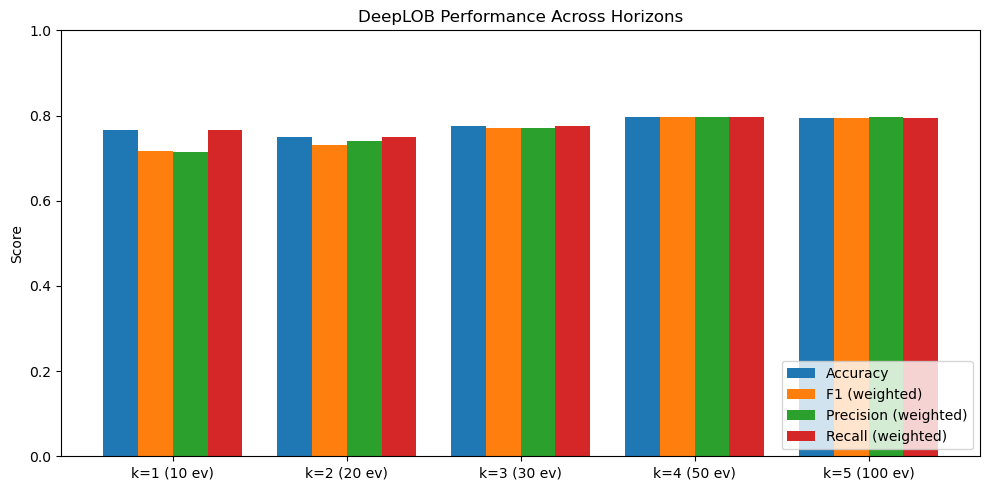

Saved comparison_horizons.png


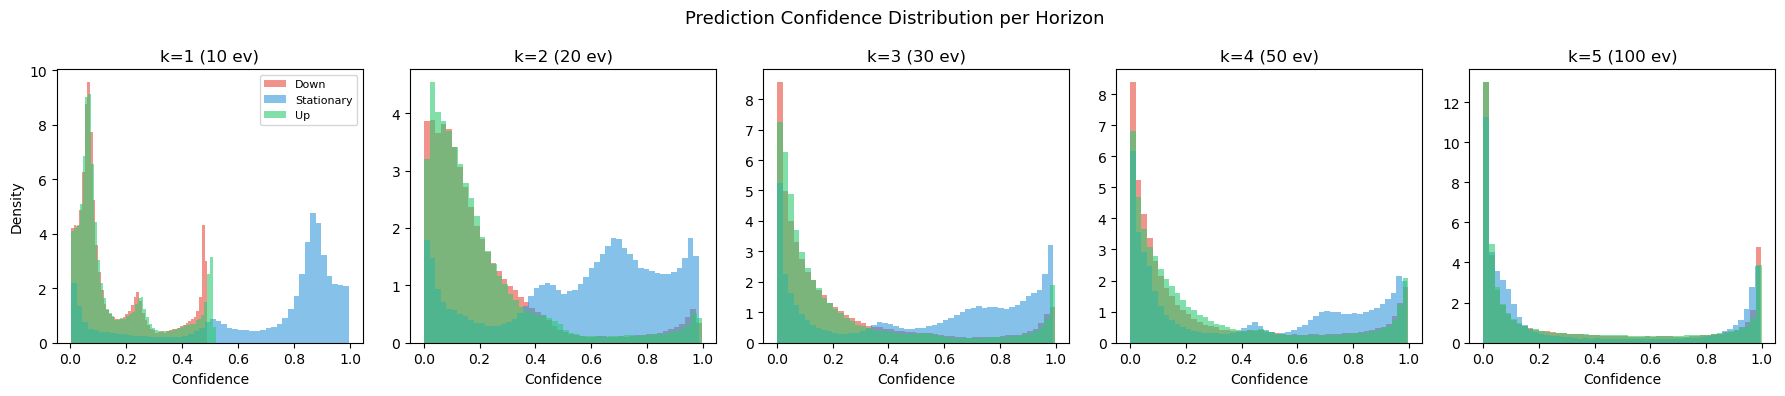

Saved confidence_dist.png


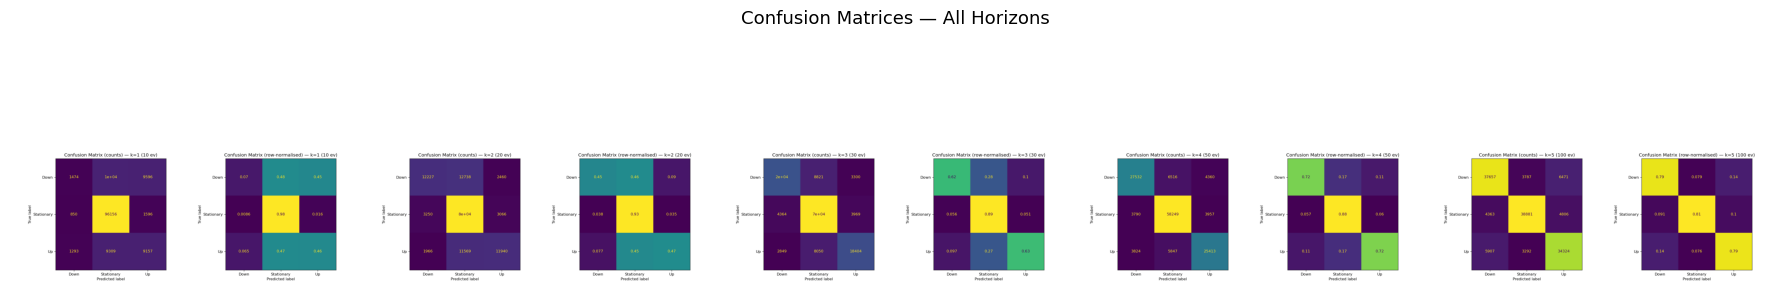

Saved all_cm_summary.png


In [21]:

# Generate missing artifact images: comparison_horizons, confidence_dist, all_cm_summary
import pickle, numpy as np, matplotlib, matplotlib.pyplot as plt, os
from matplotlib.gridspec import GridSpec
from PIL import Image as PILImage

RESULT_DIR = '/ocean/projects/mth250011p/xxiao7/DeepLOB/results'

with open(os.path.join(RESULT_DIR, 'all_results.pkl'), 'rb') as f:
    all_results = pickle.load(f)

horizons = [all_results[k]['label'] for k in range(5)]

# ── 1. comparison_horizons.png ───────────────────────────────────────────────
metrics = ['accuracy', 'f1_w', 'precision_w', 'recall_w']
labels  = ['Accuracy', 'F1 (weighted)', 'Precision (weighted)', 'Recall (weighted)']
x = np.arange(len(horizons))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
for i, (m, lab) in enumerate(zip(metrics, labels)):
    vals = [float(all_results[k][m]) for k in range(5)]
    ax.bar(x + i * width, vals, width, label=lab)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(horizons)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('DeepLOB Performance Across Horizons')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'comparison_horizons.png'), dpi=150)
plt.show()
print('Saved comparison_horizons.png')

# ── 2. confidence_dist.png ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
class_names = ['Down', 'Stationary', 'Up']
colors = ['#e74c3c', '#3498db', '#2ecc71']
for k in range(5):
    d = np.load(os.path.join(RESULT_DIR, f'preds_k{k}.npz'))
    probs = d['y_probs']
    ax = axes[k]
    for c, (name, col) in enumerate(zip(class_names, colors)):
        ax.hist(probs[:, c], bins=50, alpha=0.6, label=name, color=col, density=True)
    ax.set_title(horizons[k])
    ax.set_xlabel('Confidence')
    if k == 0:
        ax.set_ylabel('Density')
axes[0].legend(fontsize=8)
fig.suptitle('Prediction Confidence Distribution per Horizon', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'confidence_dist.png'), dpi=150)
plt.show()
print('Saved confidence_dist.png')

# ── 3. all_cm_summary.png ────────────────────────────────────────────────────
cm_imgs = [PILImage.open(os.path.join(RESULT_DIR, f'cm_k{k}.png')) for k in range(5)]
widths, heights = zip(*[im.size for im in cm_imgs])
total_w = sum(widths)
max_h   = max(heights)
combined = PILImage.new('RGB', (total_w, max_h), (255, 255, 255))
x_off = 0
for im in cm_imgs:
    combined.paste(im, (x_off, 0))
    x_off += im.size[0]
combined.save(os.path.join(RESULT_DIR, 'all_cm_summary.png'))
fig2, ax2 = plt.subplots(figsize=(18, 4))
ax2.imshow(np.array(combined))
ax2.axis('off')
fig2.suptitle('Confusion Matrices — All Horizons', fontsize=13)
plt.tight_layout()
plt.show()
print('Saved all_cm_summary.png')


## 3. Dataset and task

FI-2010 contains 149 rows per event:
- rows **0–39**: raw 10-level LOB features used by DeepLOB
- rows **40–143**: engineered features (u2–u9)
- rows **144–148**: labels for 5 prediction horizons

The main DeepLOB task is **3-class mid-price movement prediction** at horizons:
- k=1 → 10 events ahead
- k=2 → 20 events ahead
- k=3 → 30 events ahead
- k=4 → 50 events ahead
- k=5 → 100 events ahead


In [3]:
# Train / test sizes and label distribution
train_all = np.loadtxt(os.path.join(DATA_DIR, 'Train_Dst_NoAuction_DecPre_CF_7.txt'))
train = train_all[:, :int(np.floor(train_all.shape[1] * 0.8))]
val   = train_all[:, int(np.floor(train_all.shape[1] * 0.8)):]
t1 = np.loadtxt(os.path.join(DATA_DIR, 'Test_Dst_NoAuction_DecPre_CF_7.txt'))
t2 = np.loadtxt(os.path.join(DATA_DIR, 'Test_Dst_NoAuction_DecPre_CF_8.txt'))
t3 = np.loadtxt(os.path.join(DATA_DIR, 'Test_Dst_NoAuction_DecPre_CF_9.txt'))
test = np.hstack((t1, t2, t3))
print('Train:', train.shape, ' Val:', val.shape, ' Test:', test.shape)

for k_idx, k_name in enumerate(['k=1','k=2','k=3','k=4','k=5']):
    y = test[144 + k_idx] - 1
    vals, cnts = np.unique(y, return_counts=True)
    print(k_name, dict(zip(['Down','Stationary','Up'], cnts.tolist())))


Train: (149, 203800)  Val: (149, 50950)  Test: (149, 139587)
k=1 {'Down': 21167, 'Stationary': 98638, 'Up': 19782}
k=2 {'Down': 27470, 'Stationary': 86618, 'Up': 25499}
k=3 {'Down': 31941, 'Stationary': 78318, 'Up': 29328}
k=4 {'Down': 38467, 'Stationary': 66007, 'Up': 35113}
k=5 {'Down': 47976, 'Stationary': 48060, 'Up': 43551}


## 4. DeepLOB architecture

The reproduced primary model is exactly the paper's **Conv + Inception + LSTM** structure:

```
Input (B, 1, 100, 40)
  → Conv Block 1
  → Conv Block 2
  → Conv Block 3
  → Inception module
  → LSTM(hidden=64)
  → FC(3)
```

The three convolution blocks first aggregate price-volume information and order-book depth structure. The Inception block extracts multi-scale temporal patterns, and the LSTM models sequential dependence across the 100-event lookback window.


In [4]:
# Show the model definition from the training script (lightweight, no training)
from pathlib import Path
script = Path(BASE_DIR) / 'scripts' / 'train_deeplob.py'
text = script.read_text()
start = text.index('class DeepLOB')
end = text.index('def batch_gd(')
print(text[start:end].rstrip())


class DeepLOB(nn.Module):
    """DeepLOB: CNN + Inception + LSTM for LOB mid-price prediction.

    Architecture follows Zhang et al. (2019):
      Input (B, 1, T, 40) → 3 Conv blocks → Inception → LSTM → FC(3)
    """
    def __init__(self, y_len=3, dropout=0.2):
        super().__init__()
        self.y_len = y_len

        # Block 1 — price-volume level extraction
        self.conv1 = nn.Sequential(
            nn.Conv2d(1,  32, kernel_size=(1, 2), stride=(1, 2)),
            nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
        )
        # Block 2 — level aggregation
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(1, 2), stride=(1, 2)),
            nn.Tanh(), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.Tanh(), nn.

## 5. Main DeepLOB results

In [22]:
perf = pd.read_csv(os.path.join(RESULT_DIR, 'performance_summary.csv'))
perf.style.format({c: '{:.4f}' for c in perf.columns if c != 'Horizon'})


,Horizon,Accuracy,Cohen κ,MCC,F1-Down,F1-Stat,F1-Up,F1-Weighted
0,k=1 (10 ev),0.7656,0.3988,0.4255,0.1191,0.8981,0.4566,0.7176
1,k=2 (20 ev),0.7487,0.4842,0.5022,0.5450,0.8398,0.5561,0.7300
2,k=3 (30 ev),0.7752,0.6041,0.6076,0.6716,0.8474,0.6695,0.7698
3,k=4 (50 ev),0.7972,0.6782,0.6792,0.7486,0.8528,0.7386,0.7954
4,k=5 (100 ev),0.7948,0.6921,0.6923,0.7858,0.8272,0.7703,0.7952


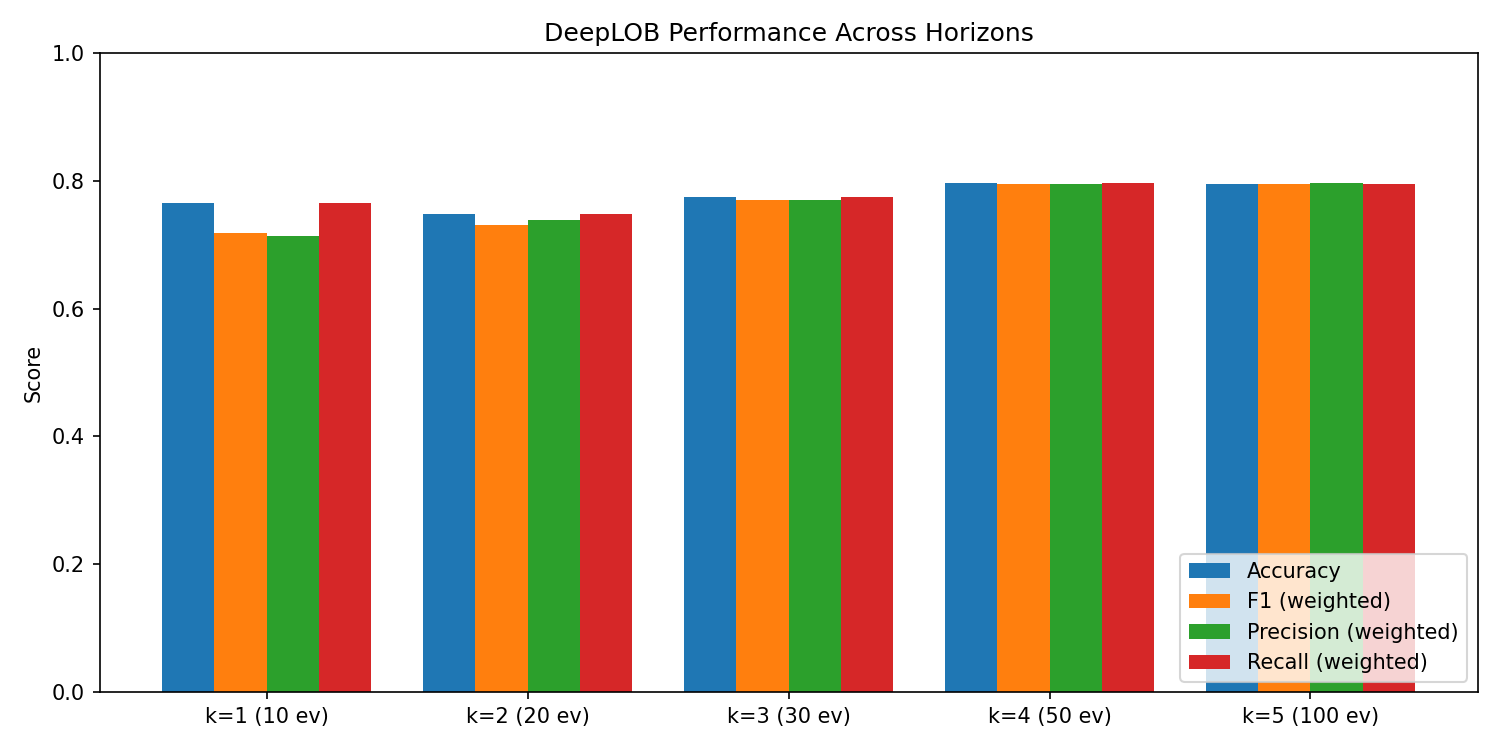

In [23]:
display(Image(os.path.join(RESULT_DIR, 'comparison_horizons.png')))


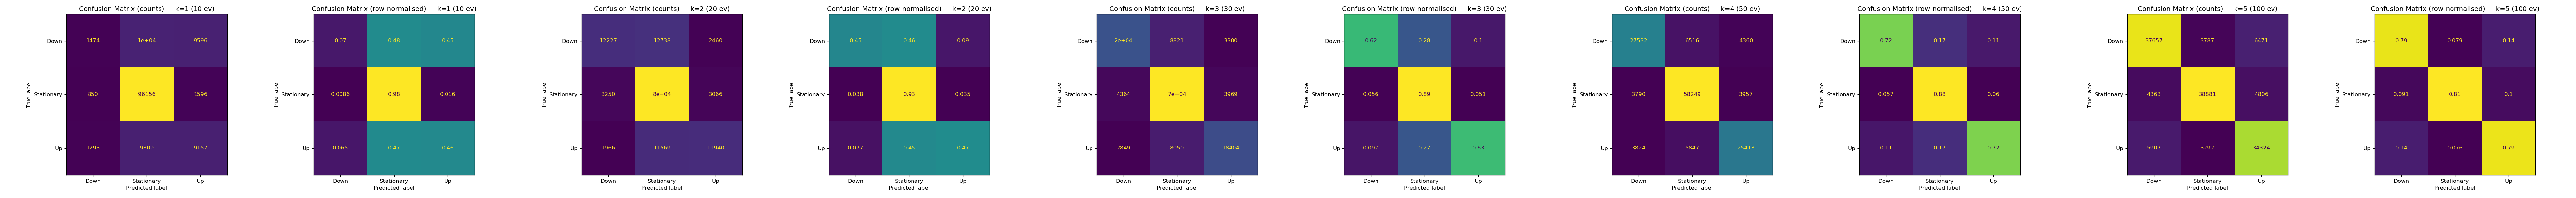

In [24]:
display(Image(os.path.join(RESULT_DIR, 'all_cm_summary.png')))


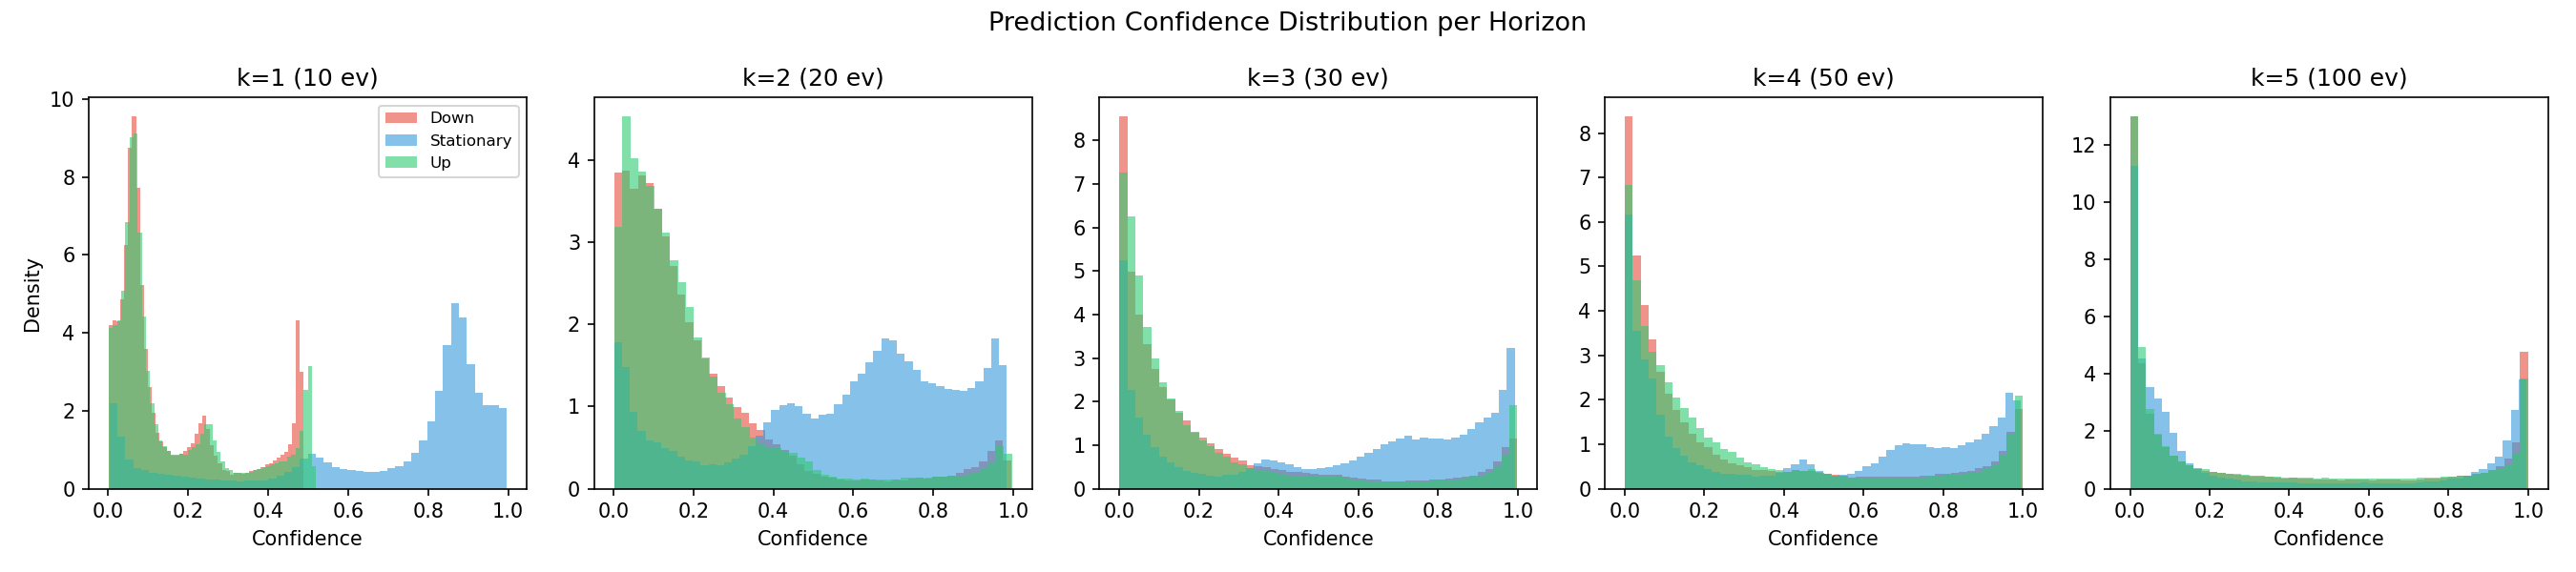

In [25]:
display(Image(os.path.join(RESULT_DIR, 'confidence_dist.png')))


### Per-horizon training curves
These curves come from the GPU training script and are loaded from `results/loss_k*.png`.


Loss curve for k=1


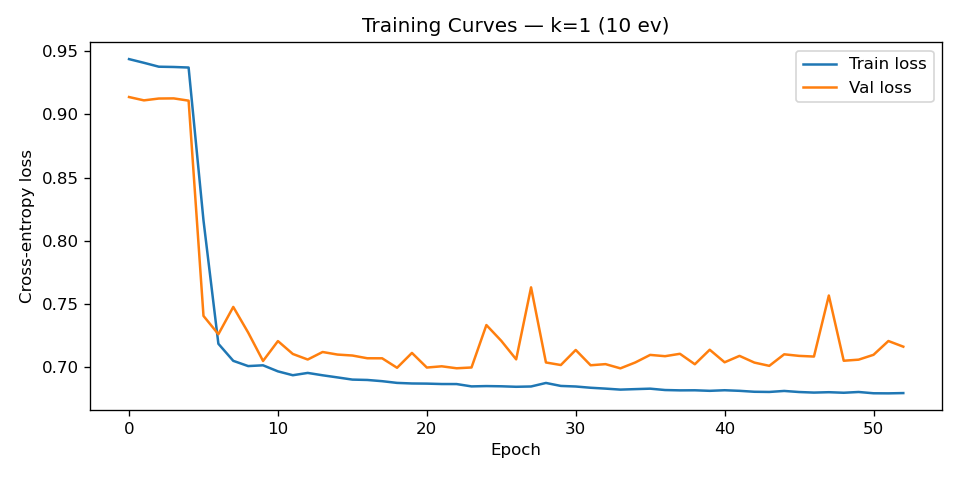

Loss curve for k=2


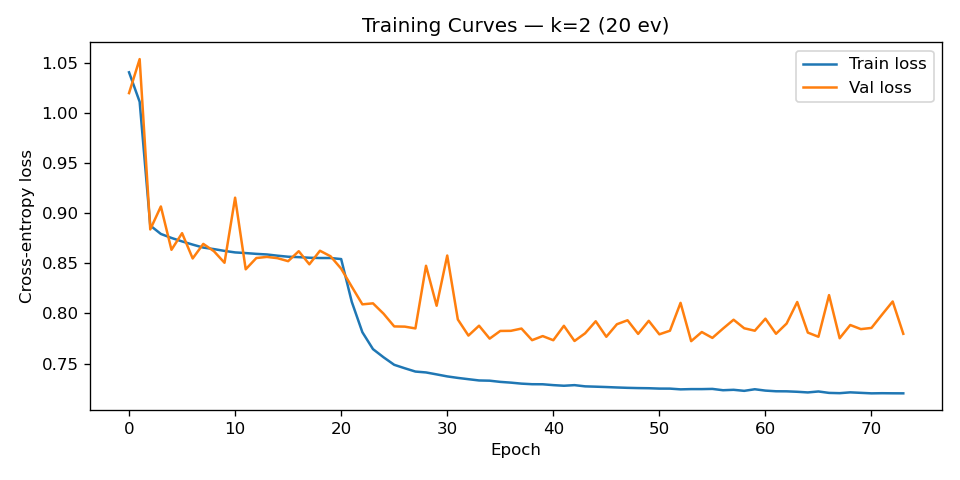

Loss curve for k=3


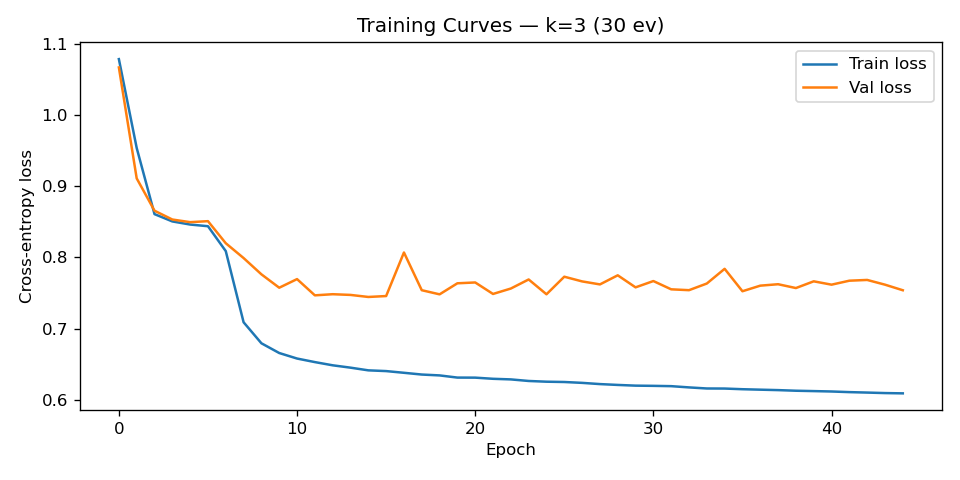

Loss curve for k=4


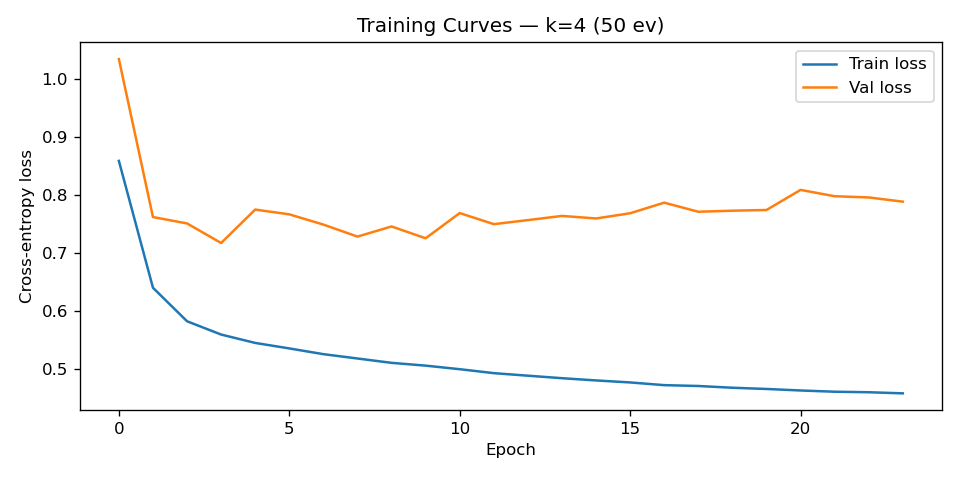

Loss curve for k=5


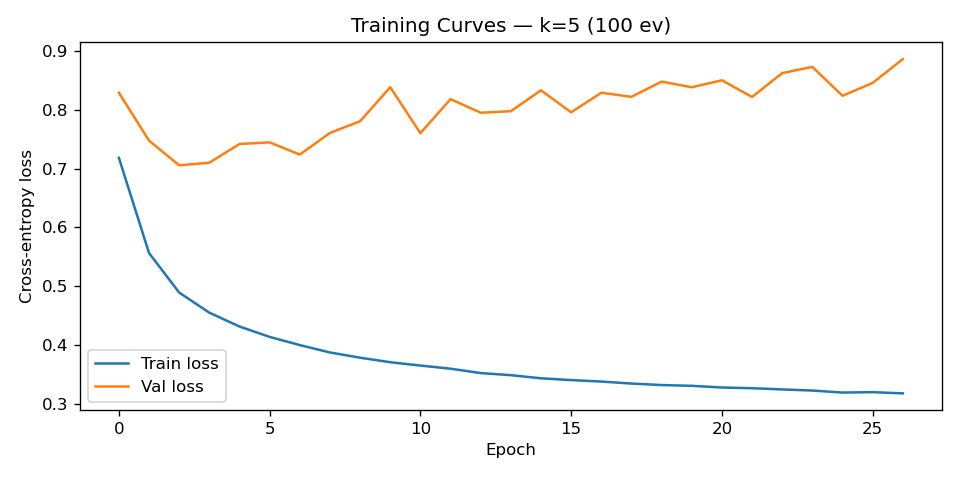

In [9]:
for k in range(5):
    print(f'Loss curve for k={k+1}')
    display(Image(os.path.join(RESULT_DIR, f'loss_k{k}.png')))


## 6. Engineered-feature statistical tests (u2–u9)

This section corresponds to the **added manual-factor analysis** on top of the original paper workflow.

Pipeline:
1. Newey-West full-sample predictability test
2. Rolling-window stability test
3. Monotonicity and Rank-IC evaluation
4. FDR (Benjamini-Hochberg) qualification


In [27]:
fp = os.path.join(RESULT_DIR, 'feature_predictability.csv')
roll = os.path.join(RESULT_DIR, 'rolling_stability.csv')
qual = os.path.join(RESULT_DIR, 'qualified_factors.csv')
if os.path.exists(fp):
    df_fp = pd.read_csv(fp)
    display(df_fp.sort_values('p_NW').head(15))
if os.path.exists(roll):
    df_roll = pd.read_csv(roll)
    display(df_roll.sort_values(['Sig ratio','Mean |t_NW|'], ascending=False).head(15))
if os.path.exists(qual):
    df_qual = pd.read_csv(qual)
    display(df_qual)


,Set,Description,Feature #,Data row,beta,t_NW,p_NW,sig_05,sig_001
46,u6,Price & Volume Derivatives,1,86,0.018467,11.285238,1.583877e-29,True,True
48,u6,Price & Volume Derivatives,3,88,0.022054,10.835288,2.382883e-27,True,True
47,u6,Price & Volume Derivatives,2,87,0.005929,8.017538,1.084505e-15,True,True
52,u6,Price & Volume Derivatives,7,92,0.016483,7.242243,4.428724e-13,True,True
55,u6,Price & Volume Derivatives,10,95,0.002469,7.172812,7.372064e-13,True,True
51,u6,Price & Volume Derivatives,6,91,0.003191,6.621797,3.557337e-11,True,True
68,u6,Price & Volume Derivatives,23,108,0.005319,6.540626,6.140581e-11,True,True
76,u6,Price & Volume Derivatives,31,116,0.003251,6.454897,1.085346e-10,True,True
72,u6,Price & Volume Derivatives,27,112,0.004032,6.453896,1.092536e-10,True,True
64,u6,Price & Volume Derivatives,19,104,0.007153,6.373906,1.846648e-10,True,True


,Set,Description,Feature #,Data row,beta_full,t_NW_full,p_NW_full,N windows,Sig windows,Sig ratio,Mean |t_NW|
4,u6,Price & Volume Derivatives,1,86,0.018467,11.285238,1.583877e-29,37,33,0.892,9.222
6,u6,Price & Volume Derivatives,3,88,0.022054,10.835288,2.382883e-27,37,33,0.892,9.197
9,u6,Price & Volume Derivatives,7,92,0.016483,7.242243,4.428724e-13,37,32,0.865,9.126
21,u6,Price & Volume Derivatives,33,118,0.001217,3.208624,1.333922e-03,37,32,0.865,6.104
14,u6,Price & Volume Derivatives,17,102,0.003741,3.934936,8.324645e-05,37,30,0.811,6.694
10,u6,Price & Volume Derivatives,8,93,-0.008885,-2.211793,2.698211e-02,37,30,0.811,3.491
7,u6,Price & Volume Derivatives,5,90,0.010358,4.737577,2.164337e-06,37,29,0.784,8.101
23,u6,Price & Volume Derivatives,37,122,0.000933,2.361126,1.822047e-02,37,29,0.784,5.204
5,u6,Price & Volume Derivatives,2,87,0.005929,8.017538,1.084505e-15,37,29,0.784,3.730
12,u6,Price & Volume Derivatives,11,96,0.010760,4.609600,4.036883e-06,37,28,0.757,8.669


,Set,Description,Feature #,Data row,beta,t_NW,p_NW,sig_05,sig_001,BH_pass
0,u3,Price Differences,11,70,-0.013217,-3.279314,1.040773e-03,True,False,True
1,u6,Price & Volume Derivatives,1,86,0.018467,11.285238,1.583877e-29,True,True,True
2,u6,Price & Volume Derivatives,2,87,0.005929,8.017538,1.084505e-15,True,True,True
3,u6,Price & Volume Derivatives,3,88,0.022054,10.835288,2.382883e-27,True,True,True
4,u6,Price & Volume Derivatives,5,90,0.010358,4.737577,2.164337e-06,True,True,True
5,u6,Price & Volume Derivatives,6,91,0.003191,6.621797,3.557337e-11,True,True,True
6,u6,Price & Volume Derivatives,7,92,0.016483,7.242243,4.428724e-13,True,True,True
7,u6,Price & Volume Derivatives,10,95,0.002469,7.172812,7.372064e-13,True,True,True
8,u6,Price & Volume Derivatives,11,96,0.010760,4.609600,4.036883e-06,True,True,True
9,u6,Price & Volume Derivatives,15,100,0.009152,5.949564,2.692940e-09,True,True,True


feature_nw_ttest.png


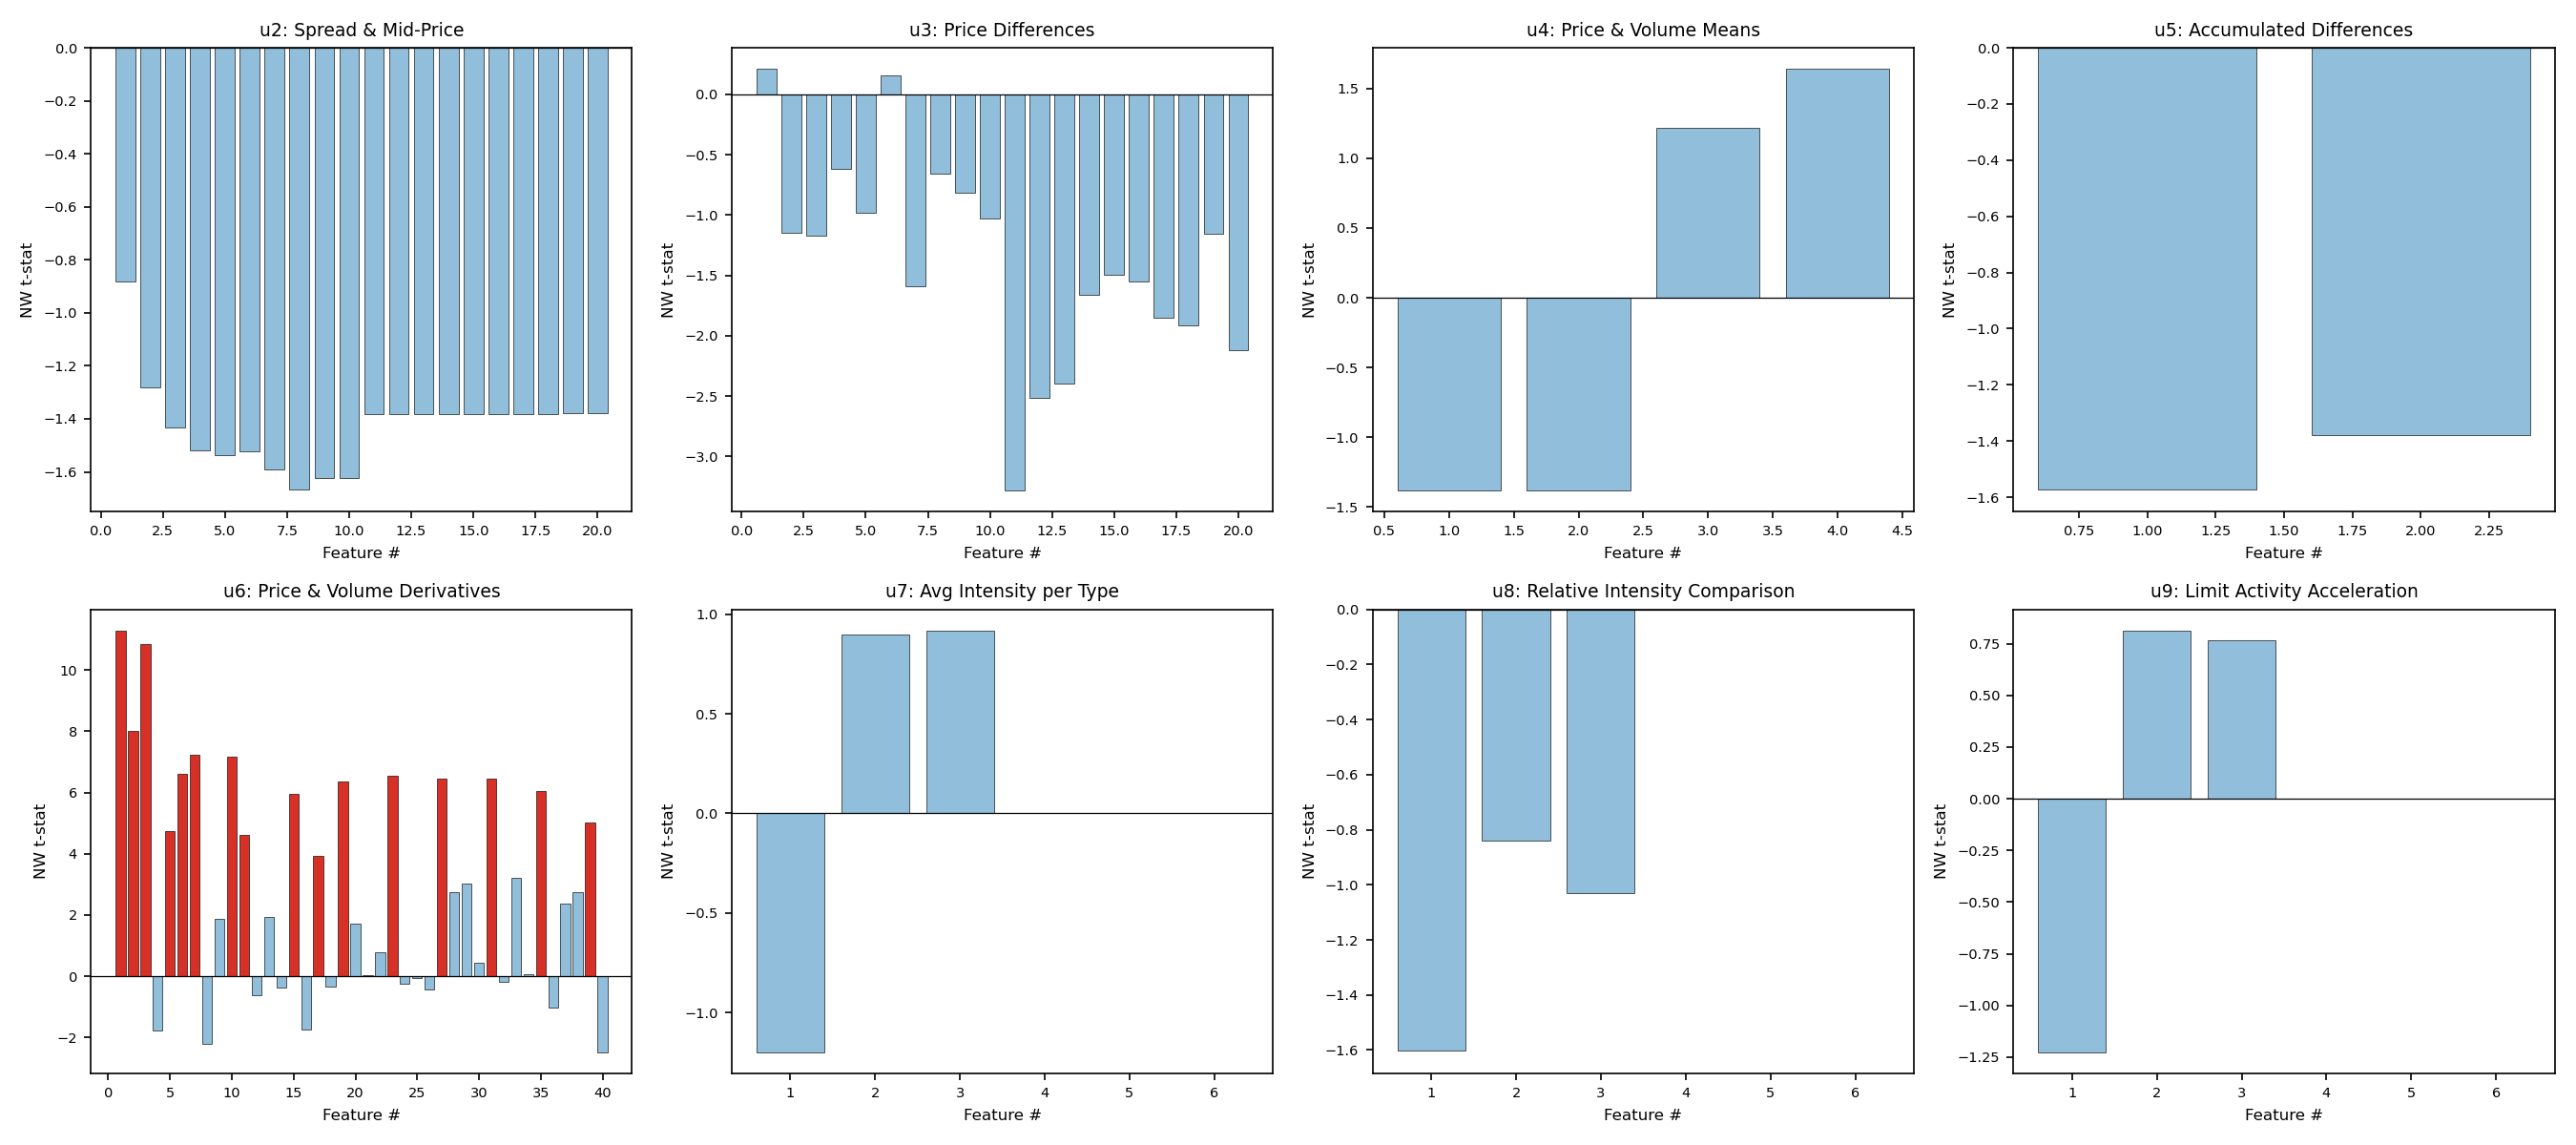

rolling_ttest.png


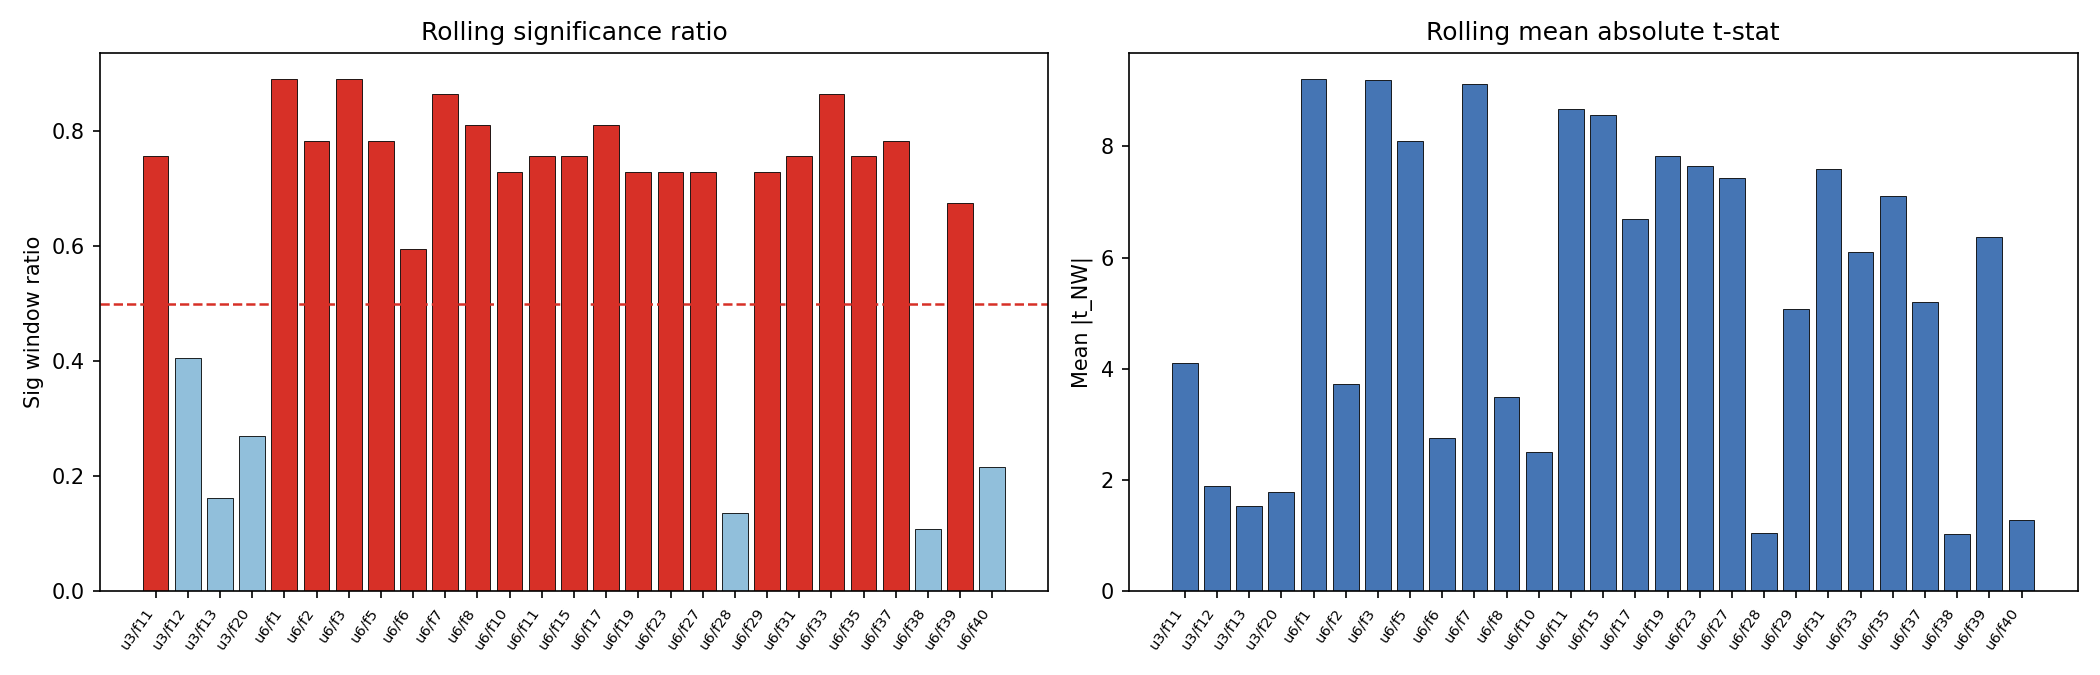

factor_monotonicity.png


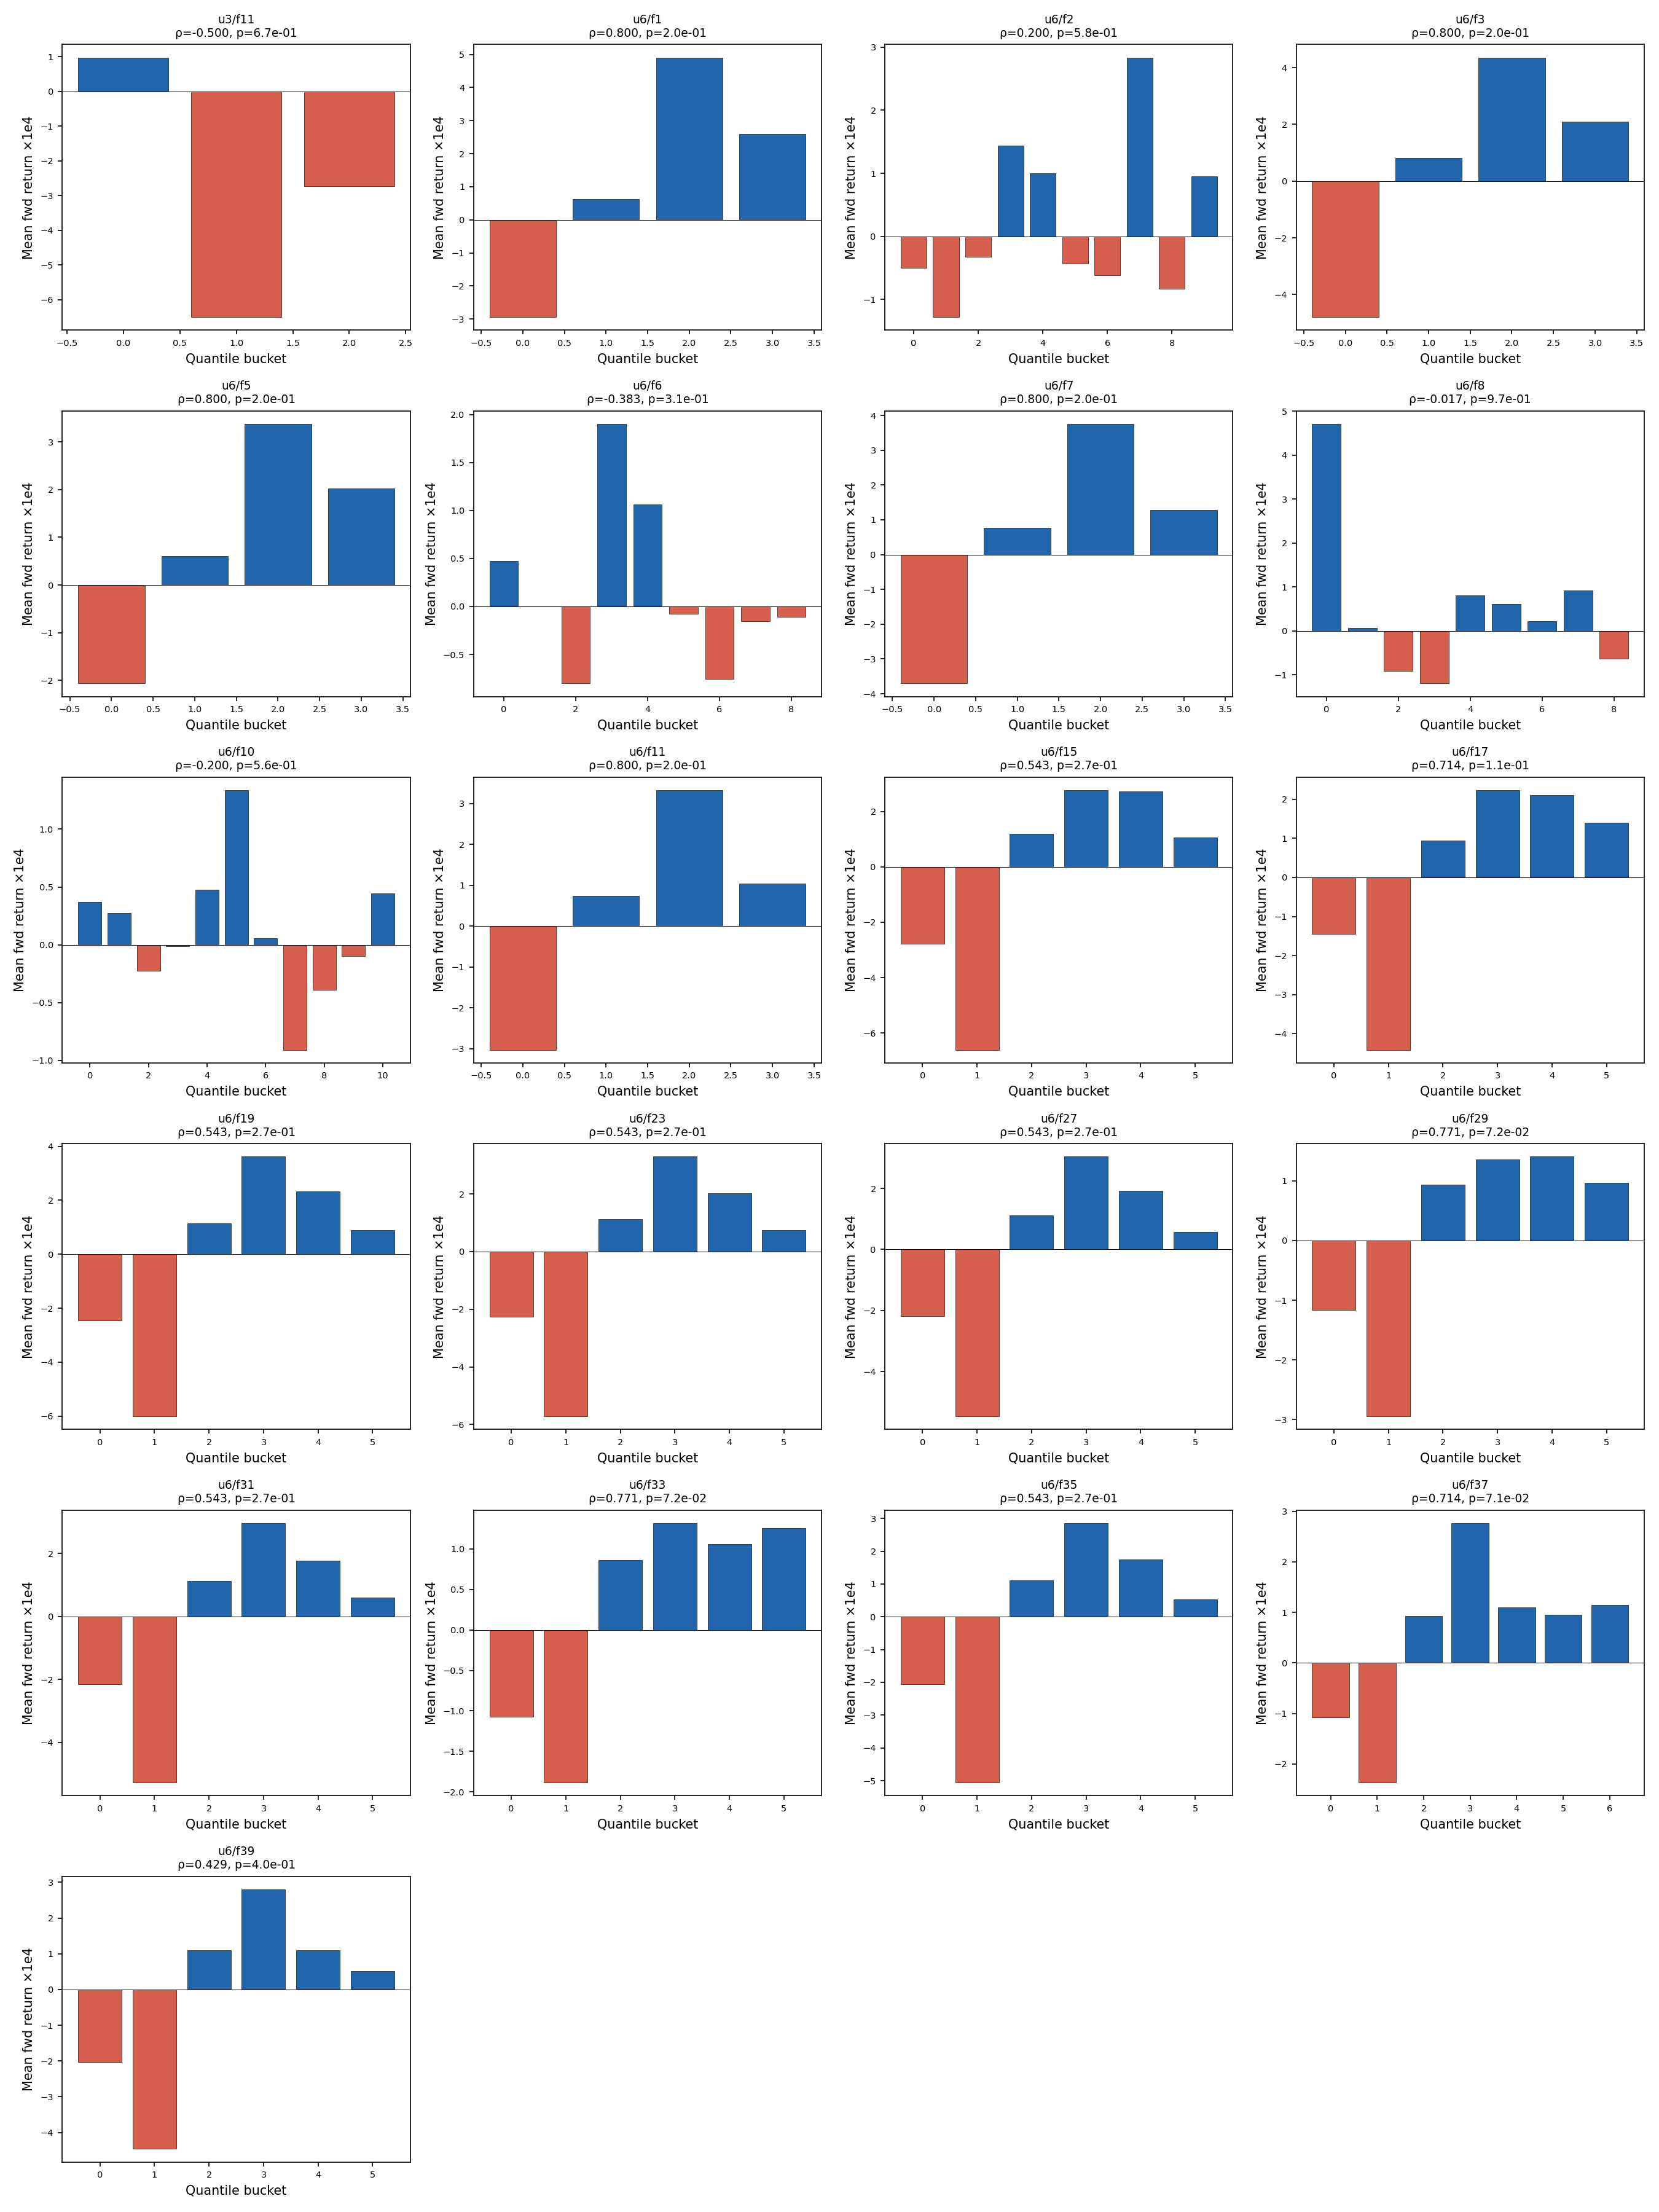

factor_rank_ic.png


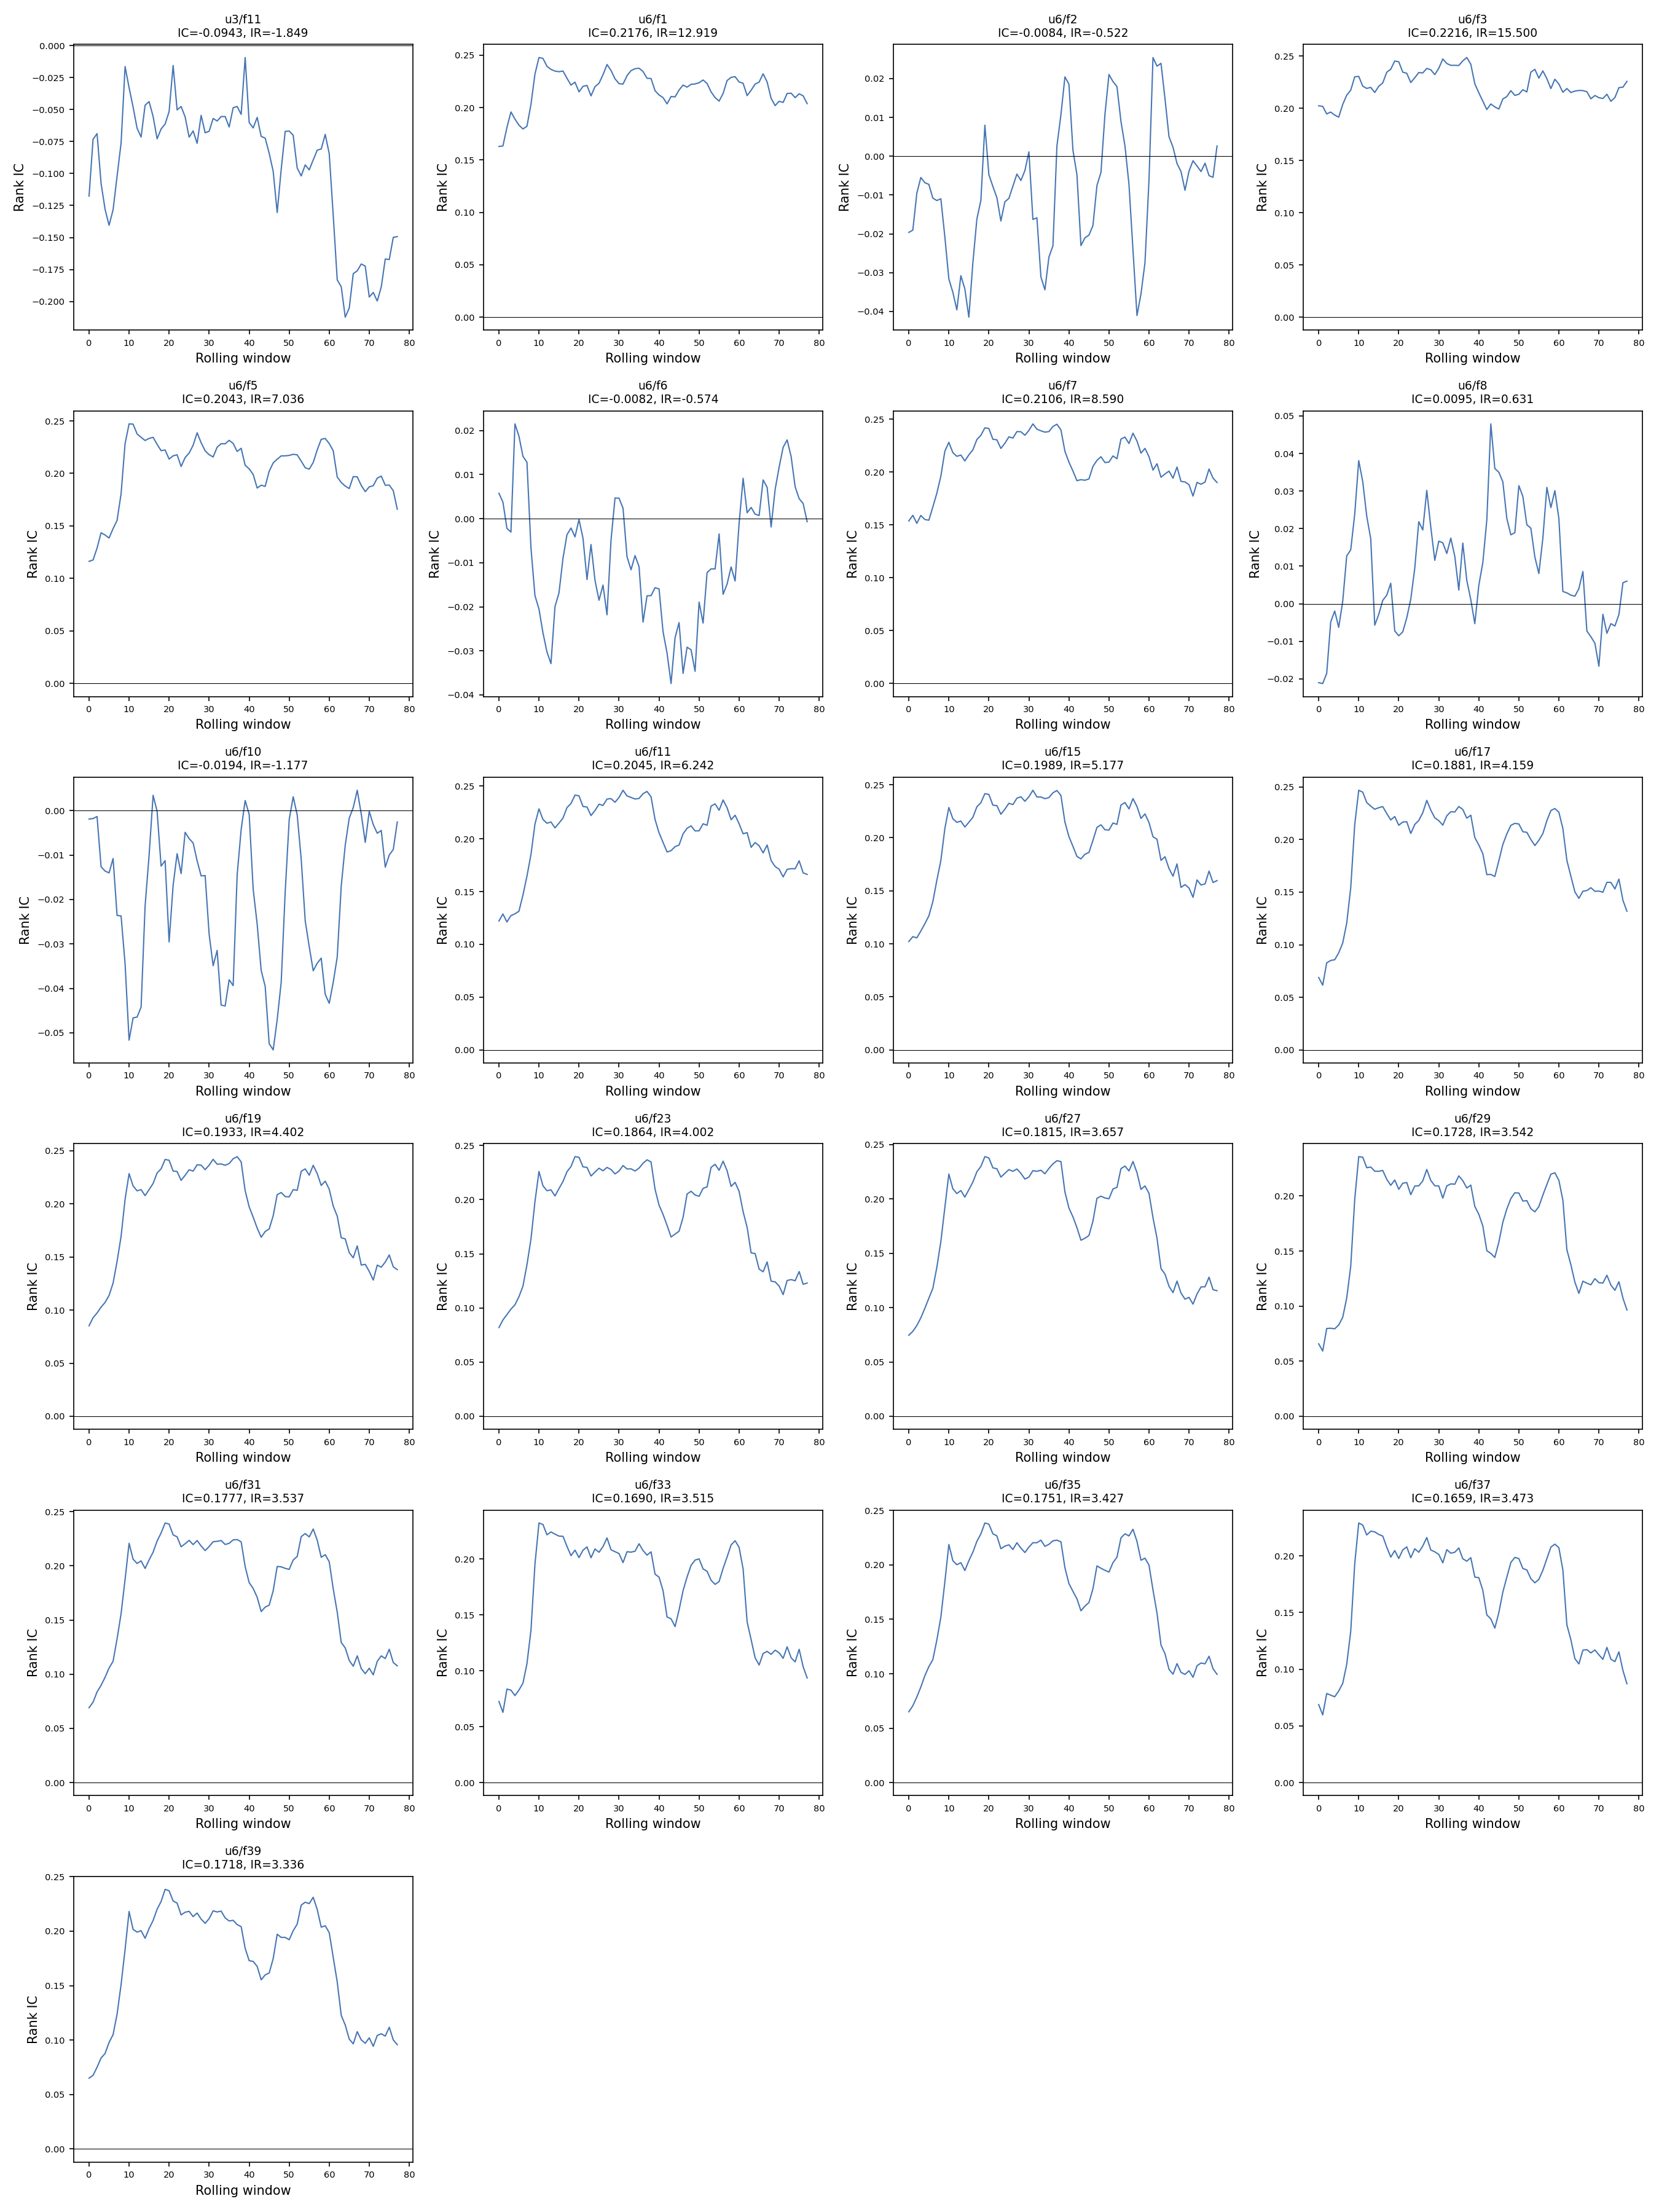

qualified_monotonicity.png


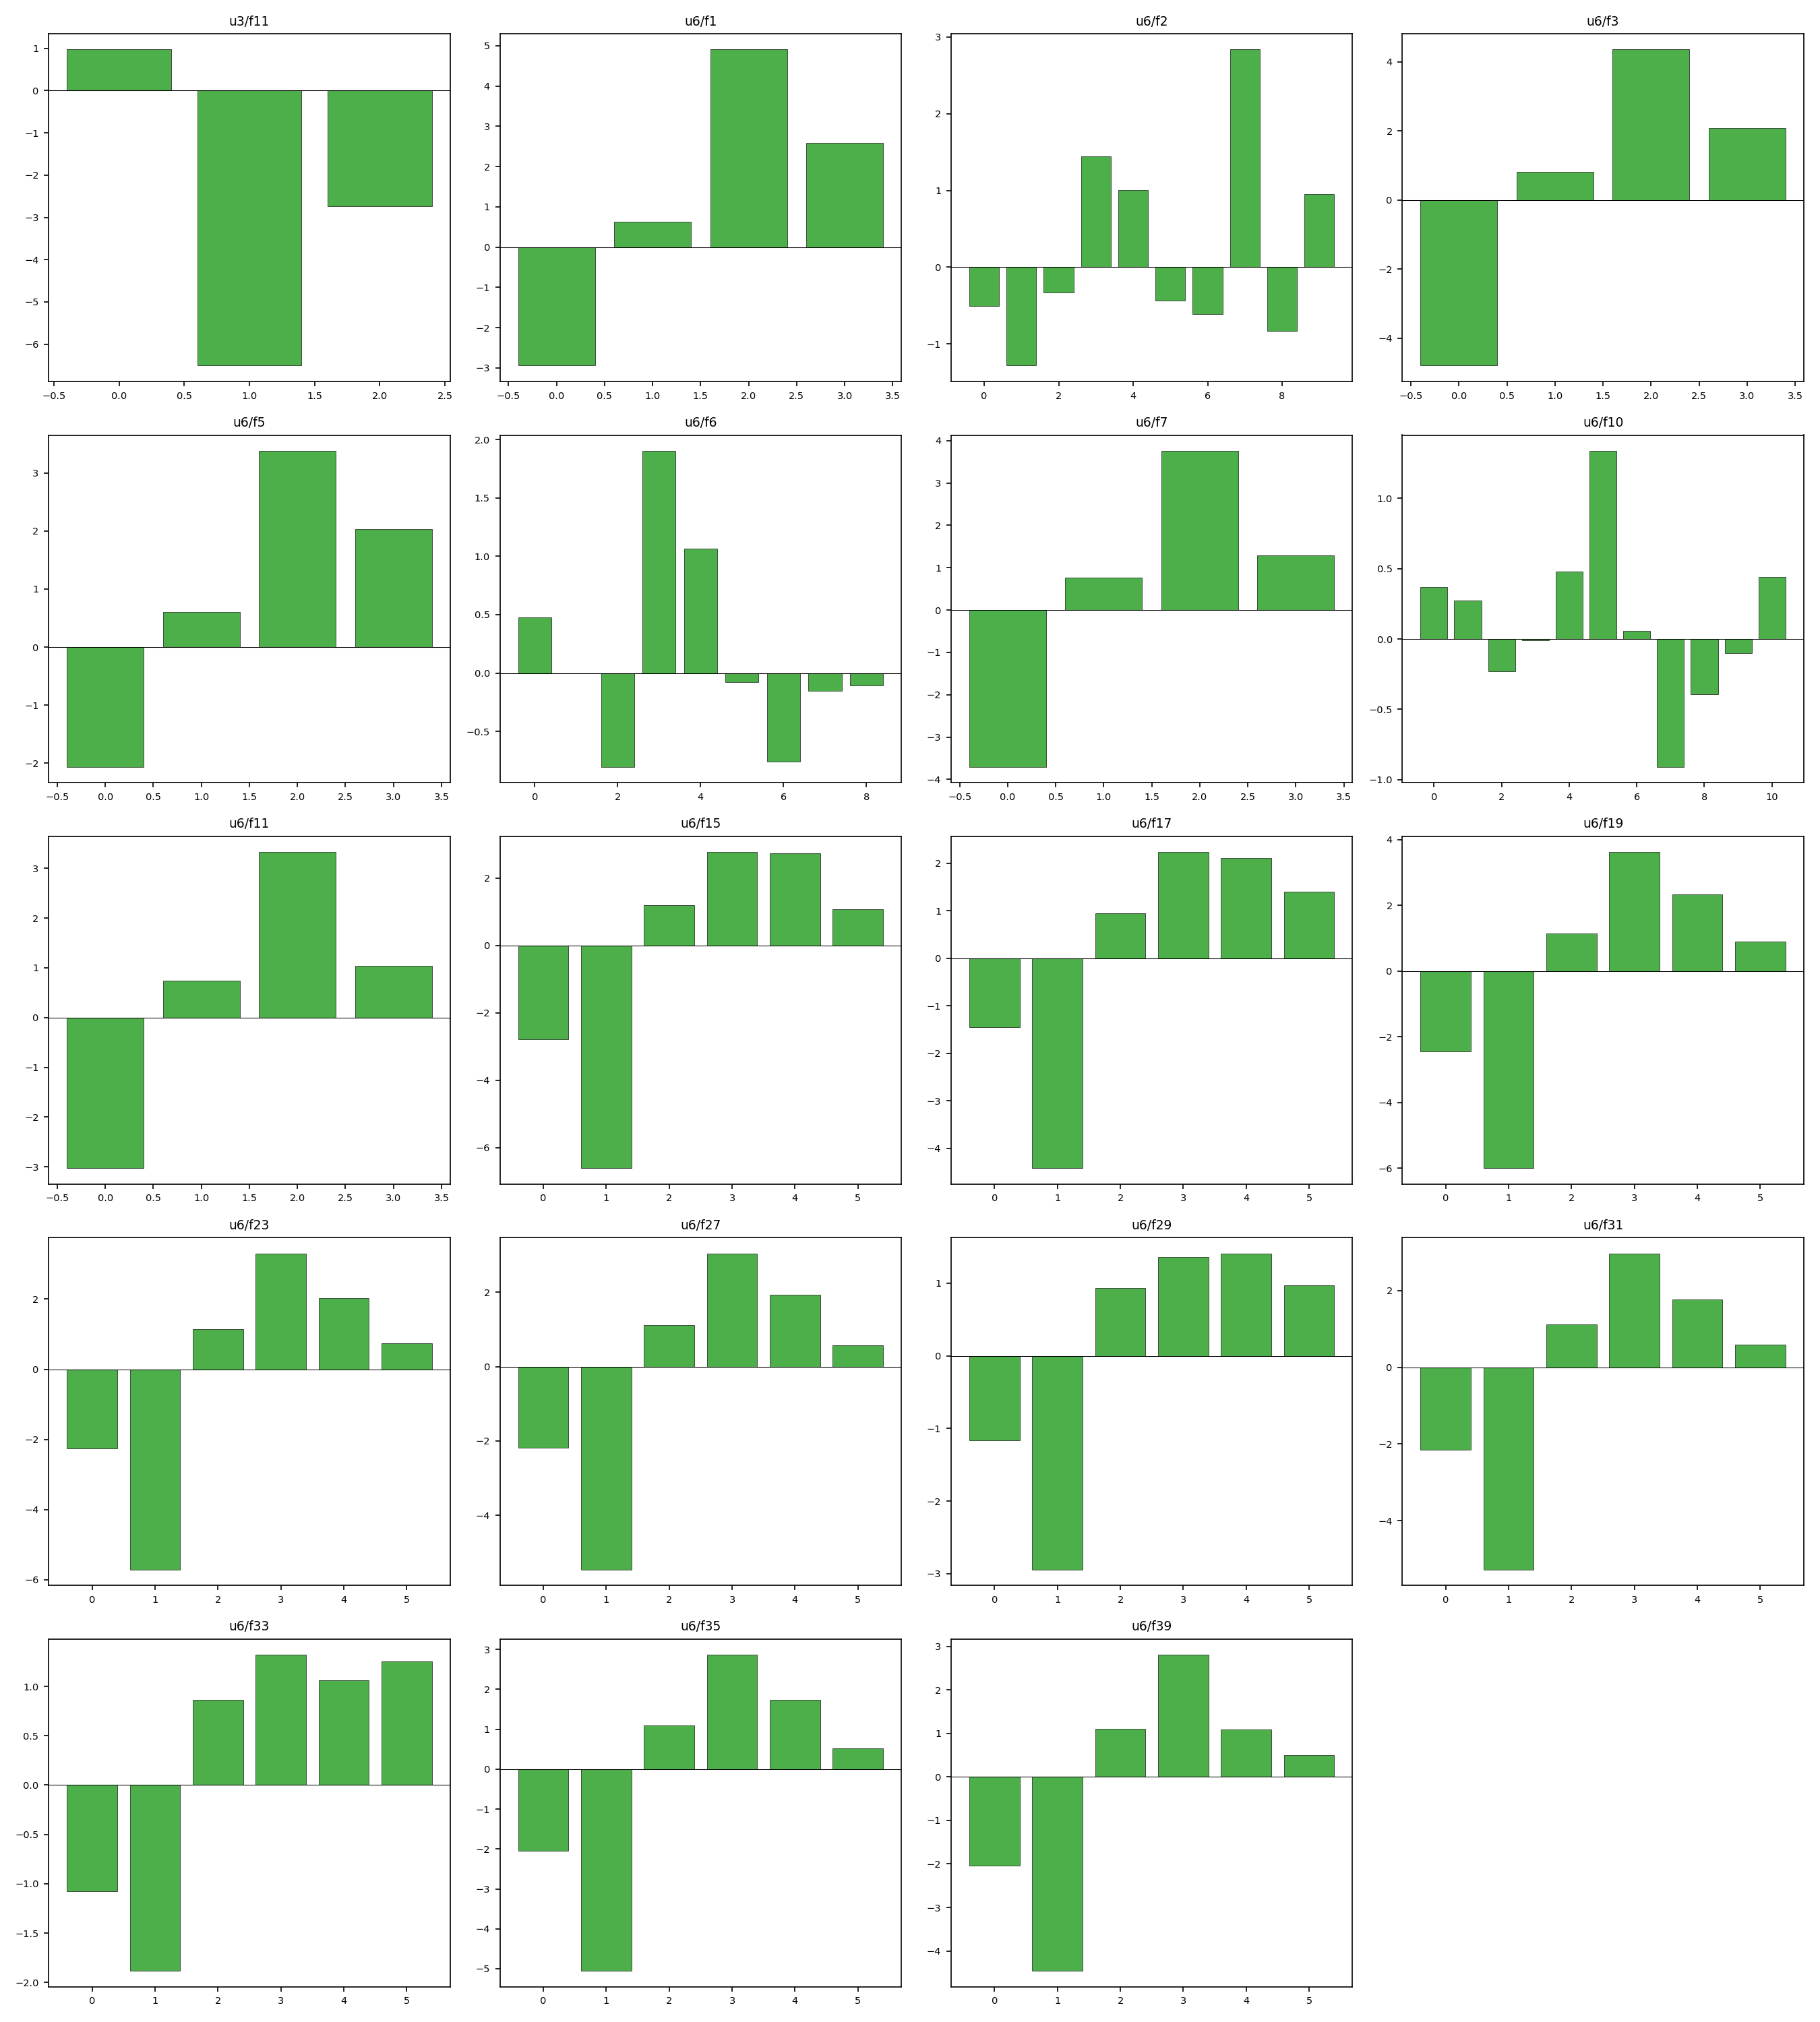

In [26]:
for name in ['feature_nw_ttest.png', 'rolling_ttest.png', 'factor_monotonicity.png', 'factor_rank_ic.png', 'qualified_monotonicity.png']:
    path = os.path.join(RESULT_DIR, name)
    if os.path.exists(path):
        print(name)
        display(Image(path))


## 7. Baseline models vs. DeepLOB

The baseline block compares DeepLOB against:
- **Ridge Logistic Regression** on qualified engineered factors
- **MLP (64-32)** on the same qualified factors

This section is designed to answer whether the manual-factor pipeline plus standard baselines can match the full DeepLOB architecture.


,Model,Accuracy,Cohen κ,MCC,F1-Down,F1-Stat,F1-Up,F1-Weighted,Sharpe-like
0,Ridge Logistic Regression,0.709912,0.004426,0.031065,0.001980,0.830542,0.007997,0.590849,0.000668
1,MLP (64-32),0.715575,0.145550,0.190847,0.124302,0.840687,0.187551,0.641534,0.019682
2,DeepLOB,0.765600,0.398800,0.425500,0.119100,0.898100,0.456600,0.717600,NaN


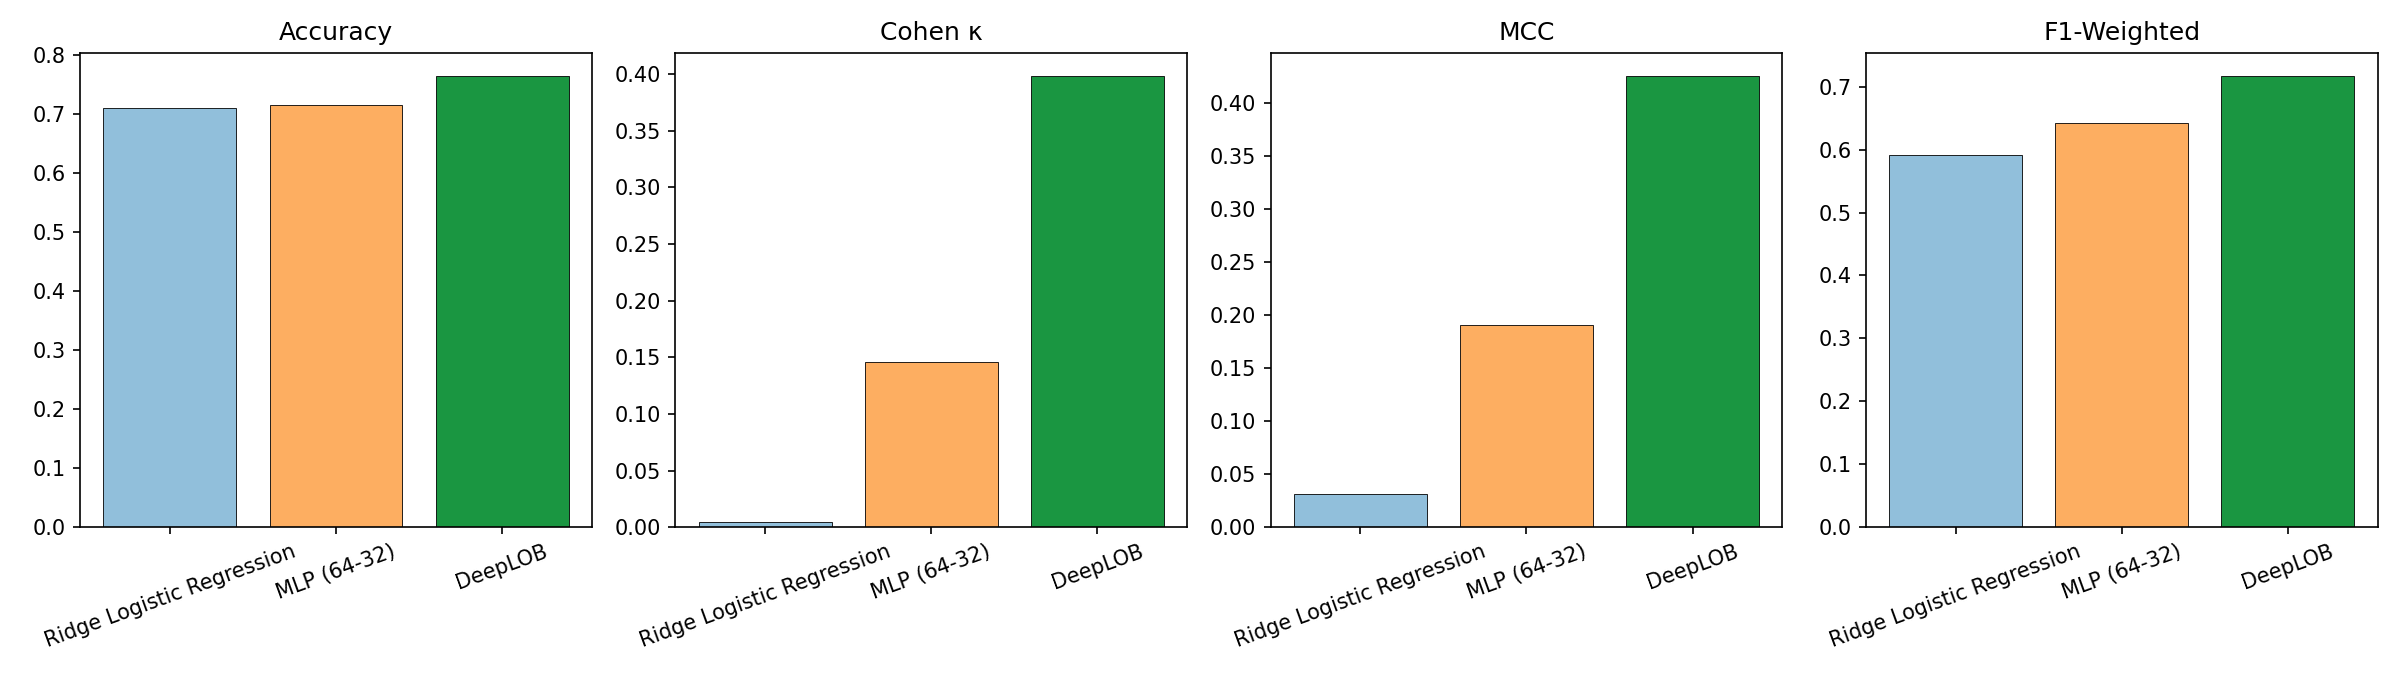

In [28]:
base_csv = os.path.join(RESULT_DIR, 'baseline_model_comparison.csv')
base_png = os.path.join(RESULT_DIR, 'baseline_comparison.png')
if os.path.exists(base_csv):
    df_base = pd.read_csv(base_csv)
    display(df_base)
else:
    print('baseline_model_comparison.csv not generated yet. Run submit_analysis.sh.')
if os.path.exists(base_png):
    display(Image(base_png))


## 8. Statistical tests and strategy-style evaluation

In [29]:
stats_csv = os.path.join(RESULT_DIR, 'statistical_tests.csv')
if os.path.exists(stats_csv):
    display(pd.read_csv(stats_csv))


,Horizon,Events ahead,Mean daily pnl,Std daily pnl,Sharpe-like,t-stat,p-value
0,k=1,10,0.023664,0.569071,0.041583,0.693335,0.488678
1,k=2,20,0.006301,0.689927,0.009133,0.152279,0.879078
2,k=3,30,0.016540,0.852599,0.019400,0.323457,0.746592
3,k=4,50,-0.116806,1.951079,-0.059867,-0.998189,0.319056
4,k=5,100,-0.328216,4.915276,-0.066775,-1.113357,0.266517


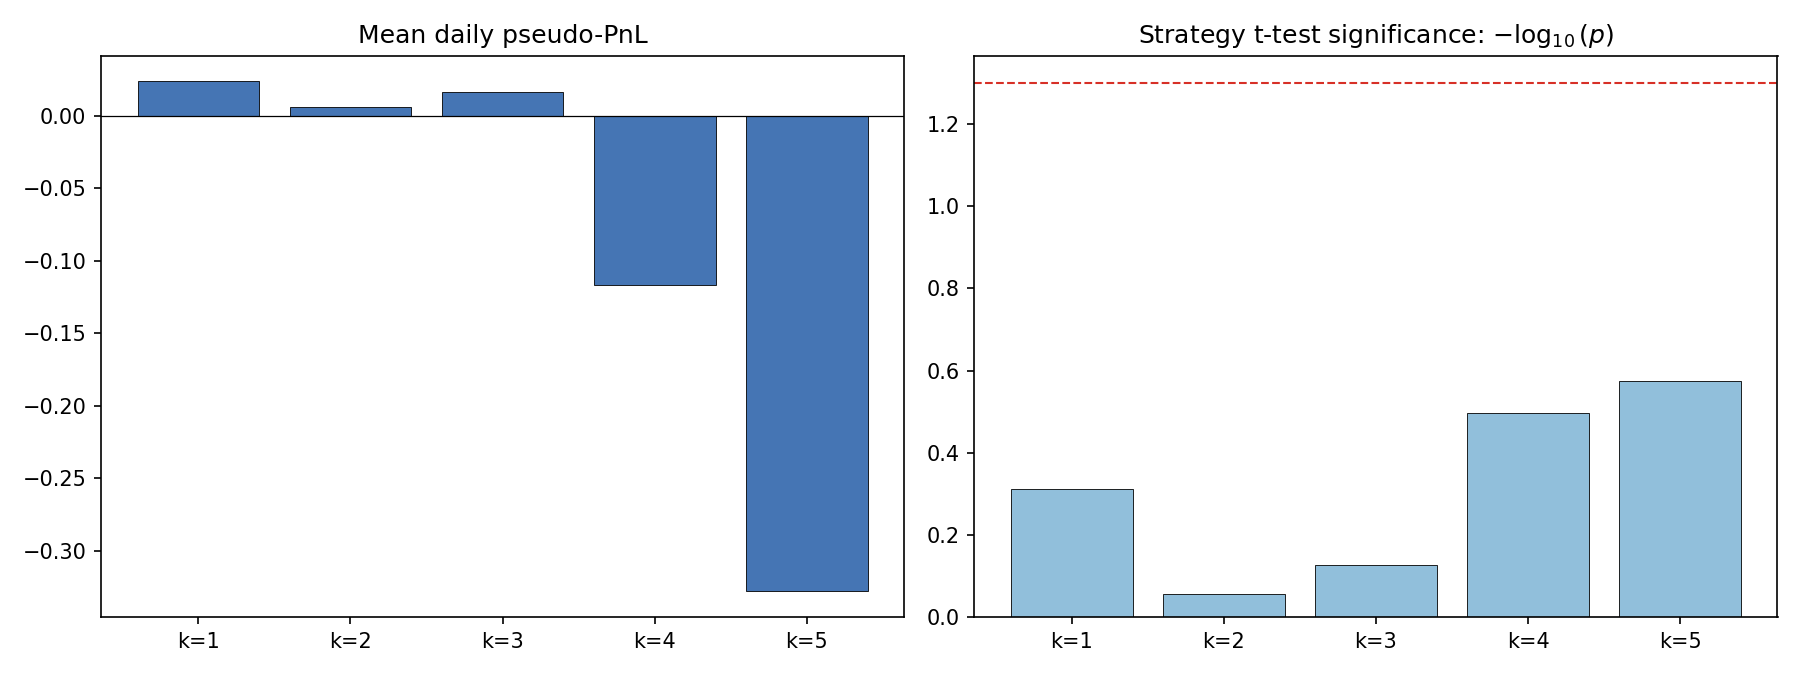

In [30]:
trade_csv = os.path.join(RESULT_DIR, 'trading_strategy_stats.csv')
if os.path.exists(trade_csv):
    display(pd.read_csv(trade_csv))
else:
    print('trading_strategy_stats.csv not generated yet. Run submit_analysis.sh.')
if os.path.exists(os.path.join(RESULT_DIR, 'trading_profit_ttest.png')):
    display(Image(os.path.join(RESULT_DIR, 'trading_profit_ttest.png')))


## 9. Interpretation summary

In [31]:
perf = pd.read_csv(os.path.join(RESULT_DIR, 'performance_summary.csv'))
best = perf.sort_values('Accuracy', ascending=False).iloc[0]
print('Best DeepLOB horizon:')
print(best.to_string())

if os.path.exists(os.path.join(RESULT_DIR, 'baseline_model_comparison.csv')):
    df_base = pd.read_csv(os.path.join(RESULT_DIR, 'baseline_model_comparison.csv'))
    print('\nBaseline comparison:')
    print(df_base.to_string(index=False))


Best DeepLOB horizon:
Horizon        k=4 (50 ev)
Accuracy            0.7972
Cohen κ             0.6782
MCC                 0.6792
F1-Down             0.7486
F1-Stat             0.8528
F1-Up               0.7386
F1-Weighted         0.7954

Baseline comparison:
                    Model  Accuracy  Cohen κ      MCC  F1-Down  F1-Stat    F1-Up  F1-Weighted  Sharpe-like
Ridge Logistic Regression  0.709912 0.004426 0.031065 0.001980 0.830542 0.007997     0.590849     0.000668
              MLP (64-32)  0.715575 0.145550 0.190847 0.124302 0.840687 0.187551     0.641534     0.019682
                  DeepLOB  0.765600 0.398800 0.425500 0.119100 0.898100 0.456600     0.717600          NaN
